##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2

### Introduction
Visual Representations (or embeddings) are high-dimensional vectors that capture the semantic meaning of an image.
In modern Computer Vision, we use Foundation Models like DINOv2 to extract these features without needing to train a model from scratch.

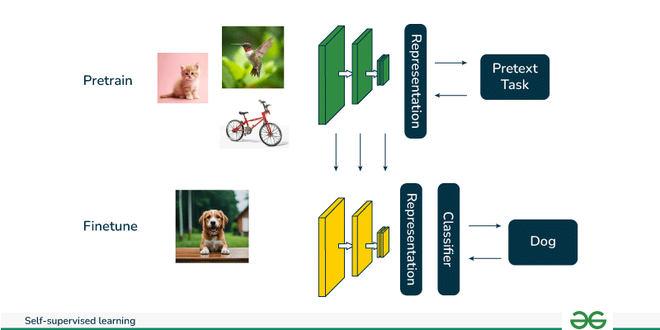

- **Global Embeddings ([CLS] token):**
    A single vector representing the entire image.
    It is used for tasks like image retrieval, classification, and clustering.
    
- **Local Embeddings (Patch tokens):**
    Spatial vectors representing small regions (patches) of the image. DINOv2 divides an image into a grid (e.g., $14 \times 14$ pixel patches).
    These are used for dense tasks like segmentation and object localization.

### Setting Up the Environment

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from transformers import AutoImageProcessor, AutoModel

# Global Configuration
MODEL_ID = "facebook/dinov2-small" # small/base/large models also exist on HF
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Foundation Model
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

print(f"Model {MODEL_ID} loaded on {device}")

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1818.91it/s]

Model facebook/dinov2-small loaded on cpu


### Global Embeddings & Semantic Similarity

A Global Embedding (the [CLS] token) is a single vector that summarizes the entire image. If two images are semantically similar (e.g., two different dogs), their vectors will point in a similar direction in high-dimensional space.

In [39]:
def get_global_embedding(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        # The first token [0, 0] is the CLS token
        cls_token = outputs.last_hidden_state[:, 0]
        return F.normalize(cls_token, p=2, dim=1)

# Compare two images
feat1 = get_global_embedding("data/dog_1.jpg")
feat2 = get_global_embedding("data/dog_2.jpg")
feat3 = get_global_embedding("data/dog_3.jpg")
feat4 = get_global_embedding("data/cat_1.jpg")


similarity_12 = torch.mm(feat1, feat2.t())
print(f"Cosine Similarity: {similarity_12.item():.4f}")

similarity_13 = torch.mm(feat1, feat3.t())
print(f"Cosine Similarity: {similarity_13.item():.4f}")

similarity_14 = torch.mm(feat1, feat4.t())
print(f"Cosine Similarity: {similarity_14.item():.4f}")

Cosine Similarity: 0.5393
Cosine Similarity: 0.3850
Cosine Similarity: -0.0317


### Patch Embeddings & Object Localization
While the CLS token gives us the "what," Patch Tokens give us the "where." DINOv2 treats the image as a grid of $14 \times 14$ pixel patches. By analyzing the variance of these patches using PCA, we can find the main object without any labels.

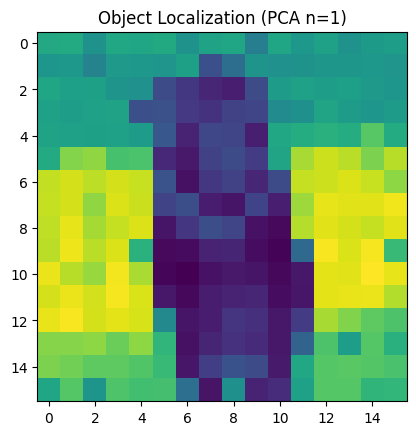

In [40]:
@torch.no_grad()
def localize_object_pca(path):
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    _, _, h, w = inputs.pixel_values.shape
    
    outputs = model(**inputs)
    # Patches start from index 1 onwards
    patches = outputs.last_hidden_state[0, 1:, :].cpu().numpy()
    
    # Apply PCA (n=1) to find the primary object
    pca = PCA(n_components=1)
    pca_output = pca.fit_transform(patches)
    
    # Reshape to grid (h/14, w/14)
    mask = pca_output.reshape(h//14, w//14)
    plt.imshow(mask, cmap='viridis')
    plt.title("Object Localization (PCA n=1)")
    plt.show()


localize_object_pca('data/dog_1.jpg')